# Day 11 - Exercise 4: Profit Margin Distribution Plot
### Task:
Using Seaborn, generate a histogram with a KDE curve (`sns.histplot(data=df, x='Profit_Margin_Pct', kde=True)`) to visualize which profit margins are most common across transactions.


C:\Users\conne\AppData\Roaming\Python\Python313\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import gaussian_kde


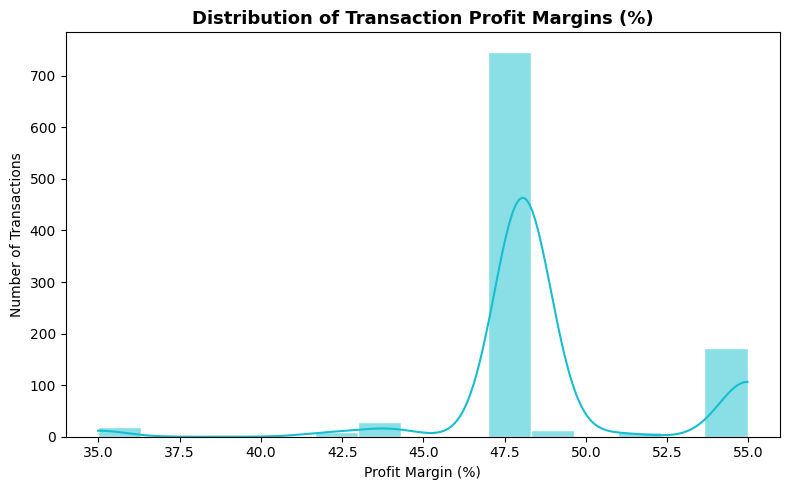

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

candidates = [Path("Sales.csv"), Path("../Sales.csv"), Path("data/Sales.csv")]
csv_file = next((p for p in candidates if p.exists()), Path("Sales.csv"))
df = pd.read_csv(csv_file)

for col in ["Total Line Revenue", "Total COGS"]:
    df[col] = df[col].astype(str).str.replace("$", "", regex=False).str.strip().astype(float)

df["Profit_Margin_Pct"] = ((df["Total Line Revenue"] - df["Total COGS"]) / df["Total Line Revenue"]) * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="Profit_Margin_Pct", kde=True, bins=15, color="#17becf", edgecolor="white", ax=ax)
ax.set_title("Distribution of Transaction Profit Margins (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Profit Margin (%)")
ax.set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()
